# Activity: Hypothesis testing with Python

## **Introduction**


Analysis of Variance (ANOVA) tests for statistically significant differences in mean values across three or more groups of x varaibles


In this activity, you will analyze historical marketing promotion data (TV, social media, radio, and influencer campaigns) to evaluate how different promotional channels drive sales.


-

You will build an OLS model, run a one-way ANOVA followed by a post hoc test (Tukey's HSD) to determine if sales vary significantly across TV and influencer categories, and deliver data-backed recommendations to stakeholders.


This includes:

* Using plots and descriptive statistics to select a categorical independent variable
* Creating and fitting a linear regression model with the selected categorical independent variable
* Checking model assumptions
* Performing and interpreting a one-way ANOVA test
* Comparing pairs of groups using an ANOVA post hoc test
* Interpreting model outputs and communicating the results to nontechnical stakeholders





## **Step 1: Imports**


Import pandas, pyplot from matplotlib, seaborn, api from statsmodels, ols from statsmodels.formula.api, and pairwise_tukeyhsd from statsmodels.stats.multicomp.

In [47]:
# Import li
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from bs4 import BeautifulSoup
import requests






`Pandas` was used to load the dataset `marketing_sales_data.csv` as `data`, now display the first five rows. The variables in the dataset have been adjusted to suit the objectives of this lab. As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [48]:
# RUN THIS CELL TO IMPORT YOUR DATA.

### YOUR CODE HERE ###
url = "https://raw.githubusercontent.com/dyyland23-glitch/Marketing_Evaluate_simple_and_multiple_regression/main/marketing_sales_data%20(1).csv"
data = pd.read_csv(url)


In [49]:

# Display the first five rows.

### YOUR CODE HERE ###


data.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


The features in the data are:
* TV promotion budget (in Low, Medium, and High categories)
* Social media promotion budget (in millions of dollars)
* Radio promotion budget (in millions of dollars)
* Sales (in millions of dollars)
* Influencer size (in Mega, Macro, Nano, and Micro categories)

**Question:** Why is it useful to perform EDAs before constructing a linear regression model?

## **Step 2: Data exploration**

First, use a boxplot to determine how `Sales` vary based on the `TV` promotion budget category.

<Axes: xlabel='TV', ylabel='Sales'>

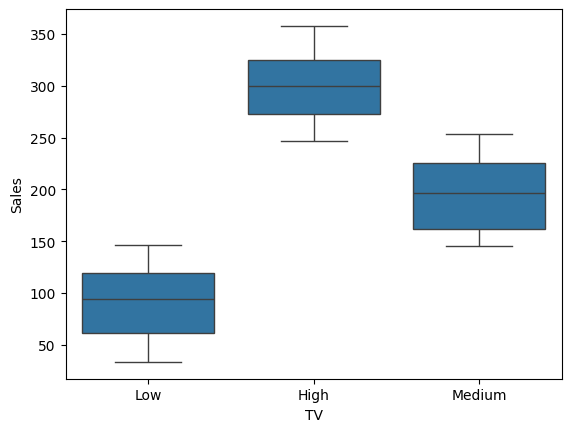

In [50]:
# Create a boxplot with TV and Sales.


sns.boxplot(x="TV",y="Sales", data=data)



**Question:** Is there variation in `Sales` based off the `TV` promotion budget?

Now, use a boxplot to determine how `Sales` vary based on the `Influencer` size category.

<Axes: xlabel='Influencer', ylabel='Sales'>

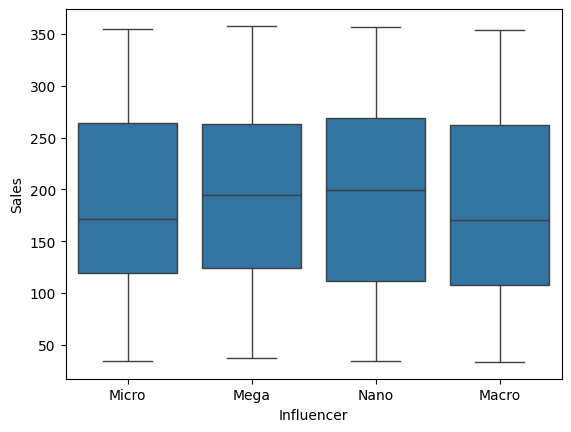

In [51]:
# Create a boxplot with Influencer and Sales.

sns.boxplot(x="Influencer",y="Sales", data=data)


**Question:** Is there variation in `Sales` based off the `Influencer` size?

### Remove missing data

You may recall from prior labs that this dataset contains rows with missing values. To correct this, drop these rows. Then, confirm the data contains no missing values.

In [52]:
# Drop rows that contain missing data and update the DataFrame.

data.isna().any(axis=0).sum()



np.int64(0)

In [53]:

# Confirm the data contains no missing values.


data[data.isna().any(axis=1)]



,TV,Radio,Social Media,Influencer,Sales


Index =0 is rows.

Index =1 is columns.

## **Step 3: Model building**


Fit a linear regression model that predicts `Sales` using one of the independent categorical variables in `data`. Refer to your previous code for defining and fitting a linear regression model.

In [54]:
from statsmodels.formula.api import ols




In [55]:
import statsmodels.formula.api as smf



In [56]:

# Define the OLS formula.
ols_formula = "Sales ~ C(TV)"



# Create an OLS model.
OLS = smf.ols(formula=ols_formula, data=data)




In [64]:
# Fit the model.
model = OLS.fit()



# Save the results summary.
model_results = model.summary()


model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Sales   R-squared:                       0.871
Model:                            OLS   Adj. R-squared:                  0.870
Method:                 Least Squares   F-statistic:                     1918.
Date:                Mon, 05 Oct 2026   Prob (F-statistic):          1.38e-253
Time:                        15:18:22   Log-Likelihood:                -2798.9
No. Observations:                 572   AIC:                             5604.
Df Residuals:                     569   BIC:                             5617.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===================================================================================
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         300.8532      2.512    119.789      0.000     295.920     305.786
C(TV)[T.Low]     -209.8691      3.394    -61.841      0.000    -216.535    -203.203
C(TV)[T.Medium]  -105.4952      3.379    -31.224      0.000    -112.131     -98.859
==============================================================================
Omnibus:                      547.584   Durbin-Watson:                   1.960
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               37.103
Skew:                           0.015   Prob(JB):                     8.77e-09
Kurtosis:                       1.753   Cond. No.                         3.97
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

**Question:** Which categorical variable did you choose for the model? Why?

### Check model assumptions

Now, check the four linear regression assumptions are upheld for your model.

**Question:** Is the linearity assumption met?

The independent observation assumption states that each observation in the dataset is independent. As each marketing promotion (row) is independent from one another, the independence assumption is not violated.

Next, verify that the normality assumption is upheld for the model.

In [58]:
# Calculate the residuals.

### YOUR CODE HERE ###





In [59]:
# Create a histogram with the residuals.

### YOUR CODE HERE ###





# Create a QQ plot of the residuals.

### YOUR CODE HERE ###



**Question:** Is the normality assumption met?

[Write your response here. Double-click (or enter) to edit.]

Now, verify the constant variance (homoscedasticity) assumption is met for this model.

In [60]:
# Create a scatter plot with the fitted values from the model and the residuals.

### YOUR CODE HERE ###


# Add a line at y = 0 to visualize the variance of residuals above and below 0.

### YOUR CODE HERE ###



**Question:** Is the constant variance (homoscedasticity) assumption met?

## **Step 4: Results and evaluation**

First, display the OLS regression results.

In [61]:
# Display the model results summary.

### YOUR CODE HERE ###



**Question:** What is your interpretation of the model's R-squared?

**Question:** What is your intepretation of the coefficient estimates? Are the coefficients statistically significant?

**Question:** Do you think your model could be improved? Why or why not? How?

### Perform a one-way ANOVA test

With the model fit, run a one-way ANOVA test to determine whether there is a statistically significant difference in `Sales` among groups.

In [62]:
# Create an one-way ANOVA table for the fit model.

### YOUR CODE HERE ###

**Question:** What are the null and alternative hypotheses for the ANOVA test?

**Question:** What is your conclusion from the one-way ANOVA test?

**Question:** What did the ANOVA test tell you?

### Perform an ANOVA post hoc test

If you have significant results from the one-way ANOVA test, you can apply ANOVA post hoc tests such as the Tukey’s HSD post hoc test.

Run the Tukey’s HSD post hoc test to compare if there is a significant difference between each pair of categories for TV.

In [63]:
# Perform the Tukey's HSD post hoc test.

### YOUR CODE HERE ###

**Question:** What is your interpretation of the Tukey HSD test?

**Question:** What did the post hoc tell you?**

## **Considerations**

**What are some key takeaways that you learned during this lab?**

[Write your response here. Double-click (or enter) to edit.]


**What summary would you provide to stakeholders? Consider the statistical significance of key relationships and differences in distribution.**

[Write your response here. Double-click (or enter) to edit.]


#### **Reference**
[Saragih, H.S. *Dummy Marketing and Sales Data*](https://www.kaggle.com/datasets/harrimansaragih/dummy-advertising-and-sales-data)

**Congratulations!** You've completed this lab. However, you may not notice a green check mark next to this item on Coursera's platform. Please continue your progress regardless of the check mark. Just click on the "save" icon at the top of this notebook to ensure your work has been logged.